# **Phase A Supplement — Missing EDA Components**

This notebook covers the four analytical gaps identified in Phase A:

| # | Section | What it adds |
|---|---------|-------------|
| 1 | **Univariate Feature Profiles** | Distribution, skewness, kurtosis, and outlier flags for every feature |
| 2 | **Time Trend Analysis** | Line charts of key indicators over 2000–2023 globally and by continent |
| 3 | **Outlier Detection & Documentation** | IQR + z-score flags, formal outlier log, exclusion decisions |
| 4 | **Feature Engineering Log** | Documented rationale for all variables kept/dropped, raw → final column mapping |

**Prerequisites:** Run `phase_a_data_exploration.ipynb` first to generate `df_merged_all_imputed.csv`

## **~Libraries~**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

CONTINENT_COLORS = {
    'Africa':        '#66c2a5',
    'Asia':          '#fc8d62',
    'Europe':        '#8da0cb',
    'North America': '#e78ac3',
    'Oceania':       '#a6d854',
    'South America': '#ffd92f',
}

## **~Load Data~**

In [2]:
df = pd.read_csv('Phase_A_docs/df_merged_all_imputed.csv')

print(f'Shape: {df.shape}')
print(f'Countries: {df["Country"].nunique()}')
print(f'Years: {df["Year"].min()} – {df["Year"].max()}')
print(f'\nColumns ({len(df.columns)}):')
for c in df.columns:
    print(f'  {c}')

Shape: (3096, 67)
Countries: 129
Years: 2000 – 2023

Columns (67):
  Country
  Year
  Acute hepatitis
  Alcohol use disorders
  Alzheimer's disease and other dementias
  Cardiovascular diseases
  Chronic kidney disease
  Chronic respiratory diseases
  Cirrhosis and other chronic liver diseases
  Conflict and terrorism
  Diabetes mellitus
  Diarrheal diseases
  Digestive diseases
  Drowning
  Drug use disorders
  Environmental heat and cold exposure
  Exposure to forces of nature
  Fire, heat, and hot substances
  HIV/AIDS
  Interpersonal violence
  Lower respiratory infections
  Malaria
  Maternal disorders
  Meningitis
  Neonatal disorders
  Neoplasms
  Nutritional deficiencies
  Parkinson's disease
  Poisonings
  Protein-energy malnutrition
  Road injuries
  Self-harm
  Tuberculosis
  Average years of schooling
  Child mortality rate
  Suicide Rate
  % GDP on Education Expenditure
  GDP per Capita
  BCG
  DTP1
  DTP3
  HepB3
  Hib3
  MCV1
  MCV2
  PCV3
  Pol3
  RCV1
  RotaC
  Homicid

In [3]:
# Identify numeric feature columns (exclude identifiers)
ID_COLS = ['Country', 'Continent', 'Year']
TARGET  = 'Life Expectancy'

feature_cols = [c for c in df.select_dtypes(include=np.number).columns
                if c not in ID_COLS + [TARGET]]

all_numeric = [TARGET] + feature_cols

print(f'Target: {TARGET}')
print(f'Features ({len(feature_cols)}): {feature_cols}')

Target: Life Expectancy
Features (63): ['Acute hepatitis', 'Alcohol use disorders', "Alzheimer's disease and other dementias", 'Cardiovascular diseases', 'Chronic kidney disease', 'Chronic respiratory diseases', 'Cirrhosis and other chronic liver diseases', 'Conflict and terrorism', 'Diabetes mellitus', 'Diarrheal diseases', 'Digestive diseases', 'Drowning', 'Drug use disorders', 'Environmental heat and cold exposure', 'Exposure to forces of nature', 'Fire, heat, and hot substances', 'HIV/AIDS', 'Interpersonal violence', 'Lower respiratory infections', 'Malaria', 'Maternal disorders', 'Meningitis', 'Neonatal disorders', 'Neoplasms', 'Nutritional deficiencies', "Parkinson's disease", 'Poisonings', 'Protein-energy malnutrition', 'Road injuries', 'Self-harm', 'Tuberculosis', 'Average years of schooling', 'Child mortality rate', 'Suicide Rate', '% GDP on Education Expenditure', 'GDP per Capita', 'BCG', 'DTP1', 'DTP3', 'HepB3', 'Hib3', 'MCV1', 'MCV2', 'PCV3', 'Pol3', 'RCV1', 'RotaC', 'Homic

---
# **1. Univariate Feature Profiles**

For every numeric feature we compute:
- **Descriptive stats** — mean, median, std, min/max, IQR
- **Shape** — skewness and kurtosis (flags for |skew| > 1 and kurt > 3)
- **Missingness** — % missing before and after imputation
- **Distribution plots** — histogram + KDE with continent color overlay

In [4]:
# ── 1a. Summary Statistics Table ──────────────────────────────────────────────

def univariate_summary(df, cols):
    """
    Compute a rich univariate summary table for a list of columns.
    Uses country-year observations (panel rows).
    """
    rows = []
    for col in cols:
        s = df[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        skew = float(stats.skew(s))
        kurt = float(stats.kurtosis(s))   # excess kurtosis (normal = 0)
        missing_pct = df[col].isna().mean() * 100

        rows.append({
            'Feature':        col,
            'N':              len(s),
            'Missing %':      round(missing_pct, 1),
            'Mean':           round(s.mean(), 3),
            'Median':         round(s.median(), 3),
            'Std':            round(s.std(), 3),
            'Min':            round(s.min(), 3),
            'Max':            round(s.max(), 3),
            'Q1':             round(q1, 3),
            'Q3':             round(q3, 3),
            'IQR':            round(iqr, 3),
            'Skewness':       round(skew, 3),
            'Kurtosis':       round(kurt, 3),
            'High Skew':      '⚠️' if abs(skew) > 1 else '',
            'Heavy Tails':    '⚠️' if abs(kurt) > 3 else '',
        })
    return pd.DataFrame(rows).set_index('Feature')

df_summary = univariate_summary(df, all_numeric)
print('Univariate Summary Table')
display(df_summary)

Univariate Summary Table


,N,Missing %,Mean,Median,Std,Min,Max,Q1,Q3,IQR,Skewness,Kurtosis,High Skew,Heavy Tails
Feature,,,,,,,,,,,,,,
Life Expectancy,3096,0.000,71.350,72.942,8.500,43.182,84.712,66.771,77.625,10.854,-0.916,0.432,,
Acute hepatitis,3096,0.000,0.731,0.156,1.150,0.000,8.136,0.043,0.932,0.888,2.406,7.006,⚠️,⚠️
Alcohol use disorders,3096,0.000,3.411,1.267,5.219,0.010,37.862,0.627,3.756,3.129,2.959,10.250,⚠️,⚠️
Alzheimer's disease and other dementias,3096,0.000,21.961,15.984,18.790,0.805,167.716,7.093,33.059,25.966,1.635,4.509,⚠️,⚠️
Cardiovascular diseases,3096,0.000,271.892,207.174,206.983,36.043,1134.247,127.889,325.502,197.613,1.704,2.562,⚠️,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
p90_p10_ratio,3096,0.000,5.951,4.921,3.019,2.738,47.997,4.036,6.833,2.797,2.704,16.558,⚠️,⚠️
bottom50_share,3096,0.000,24.931,26.017,4.997,10.248,33.983,21.738,28.521,6.783,-0.606,-0.213,,
decile1_share,3096,0.000,2.639,2.741,0.896,0.133,4.847,1.976,3.286,1.310,-0.184,-0.588,,


In [5]:
# Export summary table for reference
df_summary.to_csv('Phase_A_docs/univariate_summary.csv', index=False)
#print('✅ Saved: univariate_summary.csv')


In [6]:
# Highlight variables needing log-transformation (high skew) 
high_skew = df_summary[df_summary['High Skew'] == '⚠️'].index.tolist()
print(f'\n⚠️  High skewness (|skew| > 1) — consider log-transform in Phase C:')
for v in high_skew:
    print(f'   {v}: skew = {df_summary.loc[v, "Skewness"]}')


⚠️  High skewness (|skew| > 1) — consider log-transform in Phase C:
   Acute hepatitis: skew = 2.406
   Alcohol use disorders: skew = 2.959
   Alzheimer's disease and other dementias: skew = 1.635
   Cardiovascular diseases: skew = 1.704
   Chronic kidney disease: skew = 2.238
   Chronic respiratory diseases: skew = 1.516
   Cirrhosis and other chronic liver diseases: skew = 2.237
   Conflict and terrorism: skew = 13.365
   Diabetes mellitus: skew = 4.104
   Diarrheal diseases: skew = 3.228
   Digestive diseases: skew = 1.18
   Drowning: skew = 1.994
   Drug use disorders: skew = 5.012
   Environmental heat and cold exposure: skew = 4.912
   Exposure to forces of nature: skew = 53.636
   Fire, heat, and hot substances: skew = 2.102
   HIV/AIDS: skew = 4.435
   Interpersonal violence: skew = 3.149
   Lower respiratory infections: skew = 1.812
   Malaria: skew = 3.81
   Maternal disorders: skew = 2.503
   Meningitis: skew = 4.419
   Neonatal disorders: skew = 1.648
   Nutritional defici

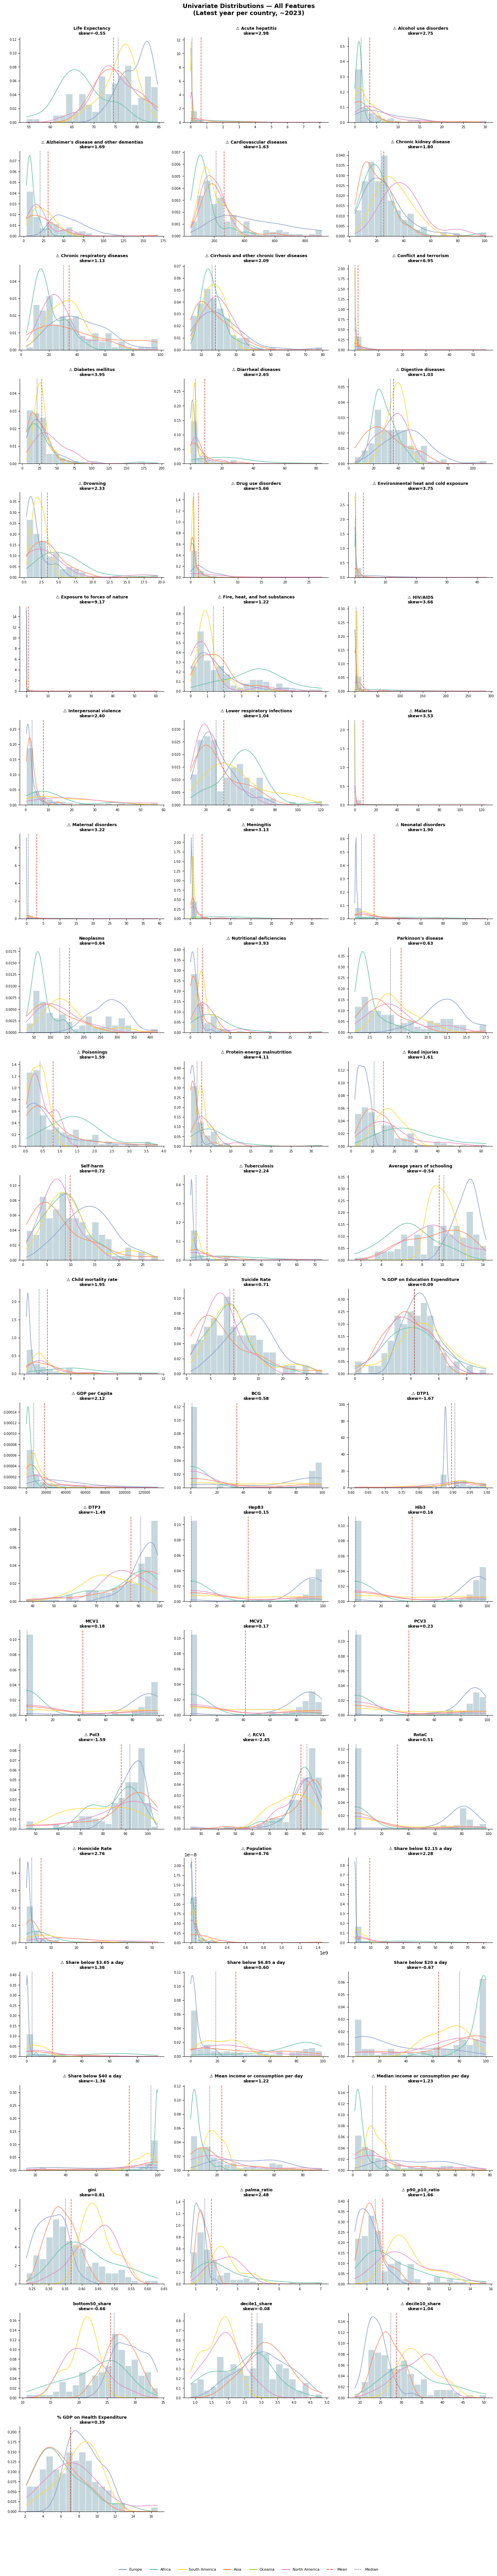

In [7]:
# ── 1b. Distribution Plots — Histogram + KDE per feature ──────────────────────

def plot_univariate_distributions(df, cols, continent_col='Continent', ncols=3, latest_only=True):
    """
    For each feature: histogram (overall) + KDE per continent.
    Uses the most recent year per country to avoid panel overrepresentation.
    """
    if latest_only:
        df_plot = df.sort_values('Year').groupby('Country').last().reset_index()
        title_suffix = f'(Latest year per country, ~{df["Year"].max()})'
    else:
        df_plot = df.copy()
        title_suffix = '(All panel observations)'

    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 3.5))
    axes = axes.flatten()

    continents = df_plot[continent_col].dropna().unique() if continent_col in df_plot.columns else []

    for ax, col in zip(axes, cols):
        data = df_plot[col].dropna()
        skew_val = stats.skew(data)

        # Overall histogram
        ax.hist(data, bins=20, color='#aec6cf', edgecolor='white', alpha=0.7, density=True)

        # KDE per continent
        if continent_col in df_plot.columns:
            for cont in continents:
                subset = df_plot[df_plot[continent_col] == cont][col].dropna()
                # Need >= 3 points AND non-zero variance for KDE
                if len(subset) >= 3 and subset.std() > 0:
                    try:
                        kde_x = np.linspace(data.min(), data.max(), 200)
                        kde = stats.gaussian_kde(subset)
                        ax.plot(kde_x, kde(kde_x),
                                color=CONTINENT_COLORS.get(cont, '#888'),
                                linewidth=1.5, label=cont, alpha=0.85)
                    except np.linalg.LinAlgError:
                        pass  # singular covariance (all values identical) — skip

        # Vertical lines for mean/median
        ax.axvline(data.mean(),   color='#e74c3c', linestyle='--', linewidth=1.2, label=f'Mean={data.mean():.1f}')
        ax.axvline(data.median(), color='#2c3e50', linestyle=':',  linewidth=1.2, label=f'Median={data.median():.1f}')

        skew_flag = '⚠️ ' if abs(skew_val) > 1 else ''
        ax.set_title(f'{skew_flag}{col}\nskew={skew_val:.2f}', fontsize=9, fontweight='bold')
        ax.set_xlabel('')
        ax.tick_params(labelsize=7)
        ax.spines[['top', 'right']].set_visible(False)

    # Turn off unused axes
    for ax in axes[len(cols):]:
        ax.set_visible(False)

    # Single legend for continents
    handles = [plt.Line2D([0], [0], color=CONTINENT_COLORS.get(c, '#888'), linewidth=2, label=c)
               for c in continents if c in CONTINENT_COLORS]
    handles += [
        plt.Line2D([0], [0], color='#e74c3c', linestyle='--', linewidth=1.5, label='Mean'),
        plt.Line2D([0], [0], color='#2c3e50', linestyle=':',  linewidth=1.5, label='Median'),
    ]
    fig.legend(handles=handles, loc='lower center', ncol=len(handles),
               fontsize=8, bbox_to_anchor=(0.5, -0.02), frameon=False)

    plt.suptitle(f'Univariate Distributions — All Features\n{title_suffix}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

plot_univariate_distributions(df, all_numeric)

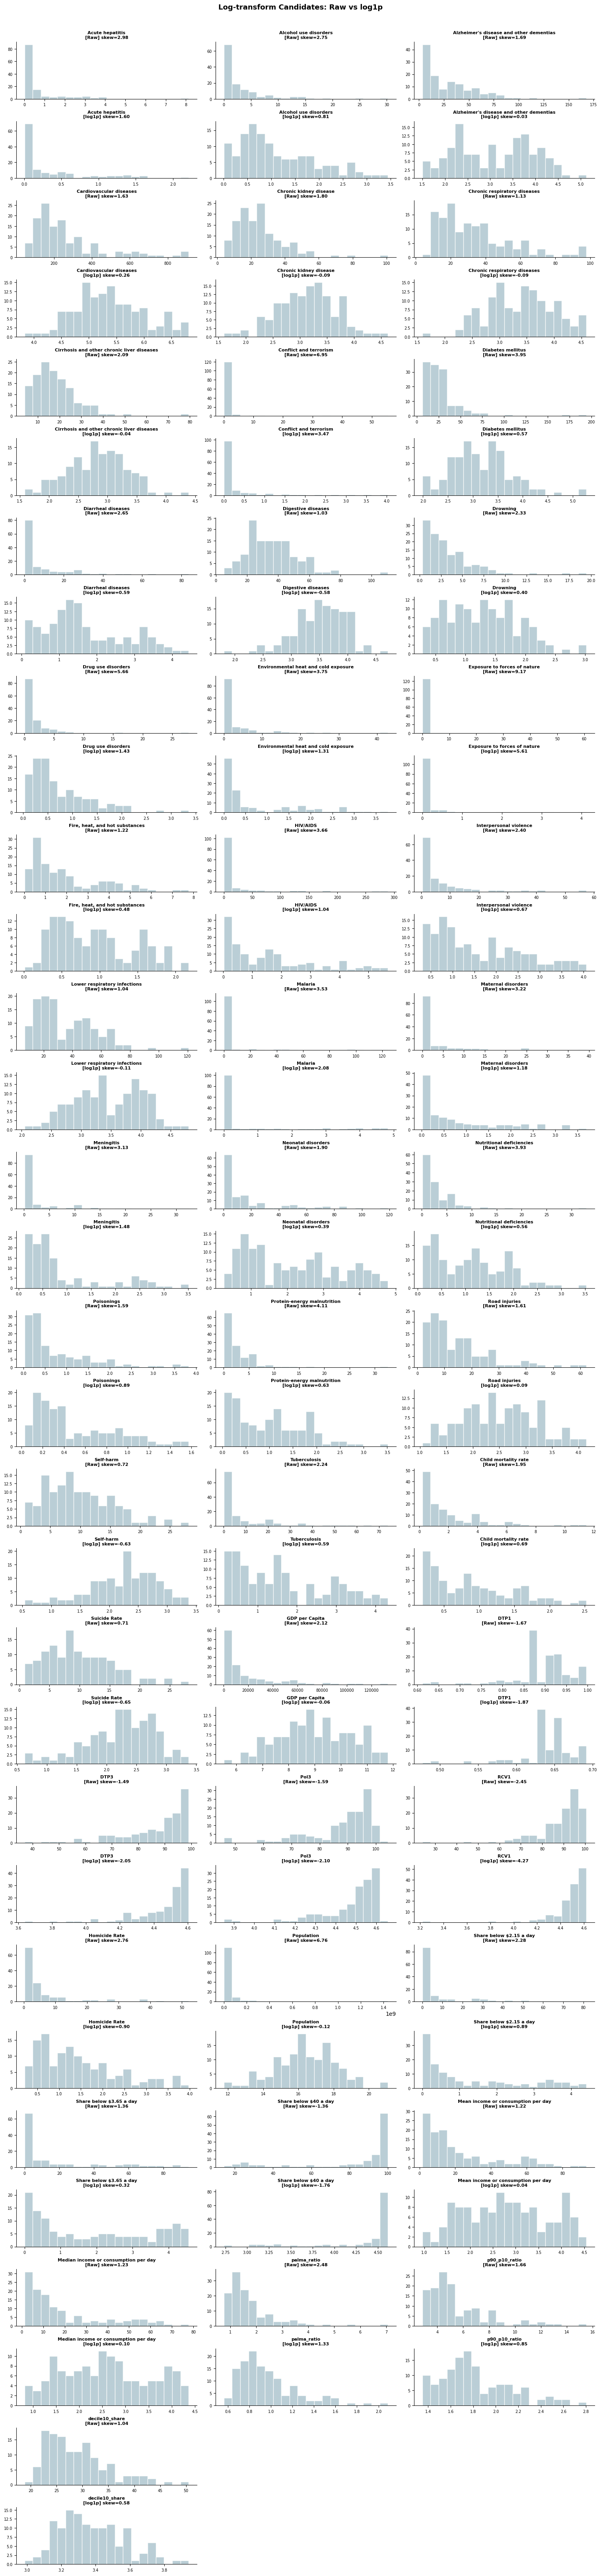

In [8]:
# ── 1c. Log-transform candidates — before vs. after comparison ─────────────────

if high_skew:
    ncols    = 3
    n_feats  = len(high_skew)
    nrows    = int(np.ceil(n_feats / ncols))   # one row per feature-group
    # Each feature occupies 2 subplot rows: top=Raw, bottom=log1p
    fig, axes = plt.subplots(nrows * 2, ncols,
                              figsize=(ncols * 5, nrows * 4),
                              constrained_layout=True)
    # Always work with a 2-D array
    if (nrows * 2) == 1:
        axes = axes[np.newaxis, :]
    
    df_latest = df.sort_values('Year').groupby('Country').last().reset_index()

    for j, col in enumerate(high_skew):
        feat_row = j // ncols          # which feature-group row (0, 1, 2 …)
        col_idx  = j % ncols           # which column (0, 1, 2)
        raw_row  = feat_row * 2        # top subplot row for this feature
        log_row  = feat_row * 2 + 1   # bottom subplot row for this feature

        raw      = df_latest[col].dropna()
        log_vals = np.log1p(raw.clip(lower=0))

        for vals, row_idx, suffix in [
            (raw,      raw_row, 'Raw'),
            (log_vals, log_row, 'log1p'),
        ]:
            ax = axes[row_idx, col_idx]
            ax.hist(vals, bins=20, color='#aec6cf', edgecolor='white', alpha=0.85)
            ax.set_title(f'{col}\n[{suffix}] skew={stats.skew(vals):.2f}',
                         fontsize=8, fontweight='bold')
            ax.spines[['top', 'right']].set_visible(False)
            ax.tick_params(labelsize=7)

    # Hide unused subplots in the last partial row
    for k in range(n_feats, nrows * ncols):
        feat_row = k // ncols
        col_idx  = k % ncols
        axes[feat_row * 2,     col_idx].set_visible(False)
        axes[feat_row * 2 + 1, col_idx].set_visible(False)

    plt.suptitle('Log-transform Candidates: Raw vs log1p',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.show()

else:
    print('No features with |skew| > 1 — no log-transform candidates.')

---
# **2. Time Trend Analysis**

For each key indicator, we show:
- **Global trend** — mean ± std band over 2000–2023
- **Continental divergence** — one line per continent
- **LE convergence index** — cross-country SD of Life Expectancy normalized to 2000 = 100 (already in main notebook, extended here to other indicators)

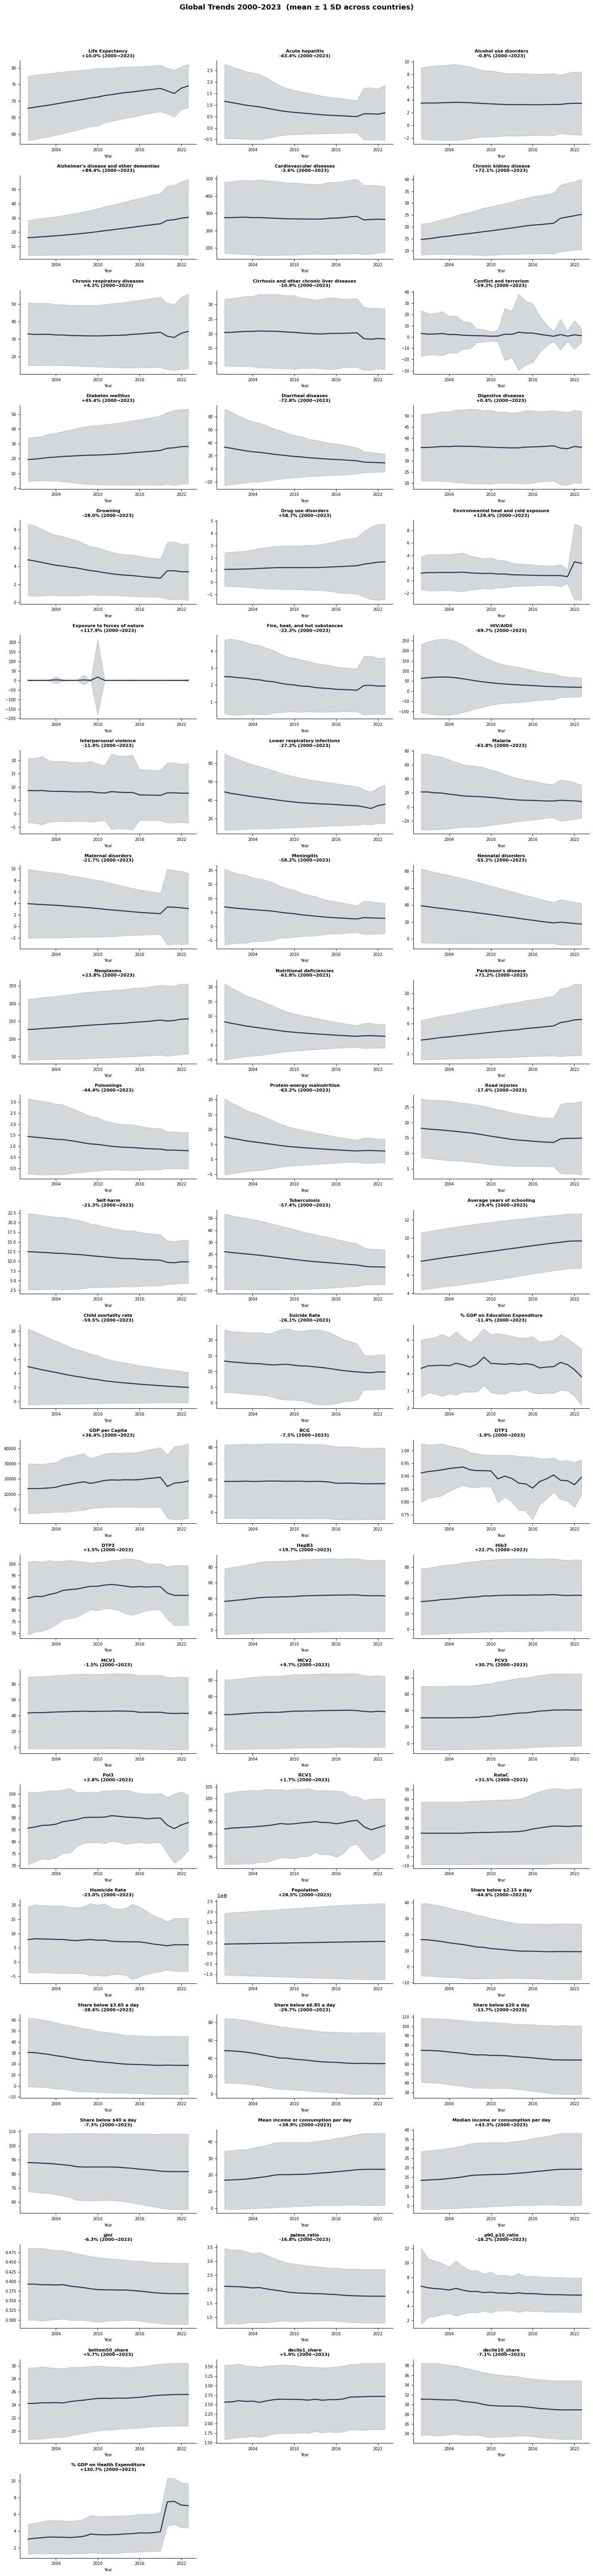

In [9]:
# ── 2a. Global Mean ± 1 SD trend for all numeric features ─────────────────────

def plot_global_trends(df, cols, ncols=3):
    """
    Line chart of annual global mean ± 1 SD for each feature.
    """
    yearly = df.groupby('Year')[cols].agg(['mean', 'std']).reset_index()

    n_feats = len(cols)
    ncols   = min(ncols, n_feats)          # never more columns than features
    nrows   = int(np.ceil(n_feats / ncols))

    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(ncols * 5, nrows * 3),
                              squeeze=False)   # ← always returns 2-D array
    axes_flat = axes.flatten()

    for i, col in enumerate(cols):
        ax        = axes_flat[i]
        mean_vals = yearly[(col, 'mean')]
        std_vals  = yearly[(col, 'std')]
        years     = yearly['Year']

        ax.plot(years, mean_vals, color='#2c3e50', linewidth=2)
        ax.fill_between(years,
                        mean_vals - std_vals,
                        mean_vals + std_vals,
                        alpha=0.2, color='#2c3e50')

        pct_change = (mean_vals.iloc[-1] - mean_vals.iloc[0]) / abs(mean_vals.iloc[0]) * 100
        sign = '+' if pct_change >= 0 else ''
        ax.set_title(f'{col}\n{sign}{pct_change:.1f}% (2000→{int(years.iloc[-1])})',
                     fontsize=8, fontweight='bold')
        ax.set_xlabel('Year', fontsize=7)
        ax.tick_params(labelsize=7)
        ax.spines[['top', 'right']].set_visible(False)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(5, integer=True))

    # Hide unused subplots in the last partial row
    for ax in axes_flat[n_feats:]:
        ax.set_visible(False)

    plt.suptitle('Global Trends 2000–2023  (mean ± 1 SD across countries)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

plot_global_trends(df, all_numeric)

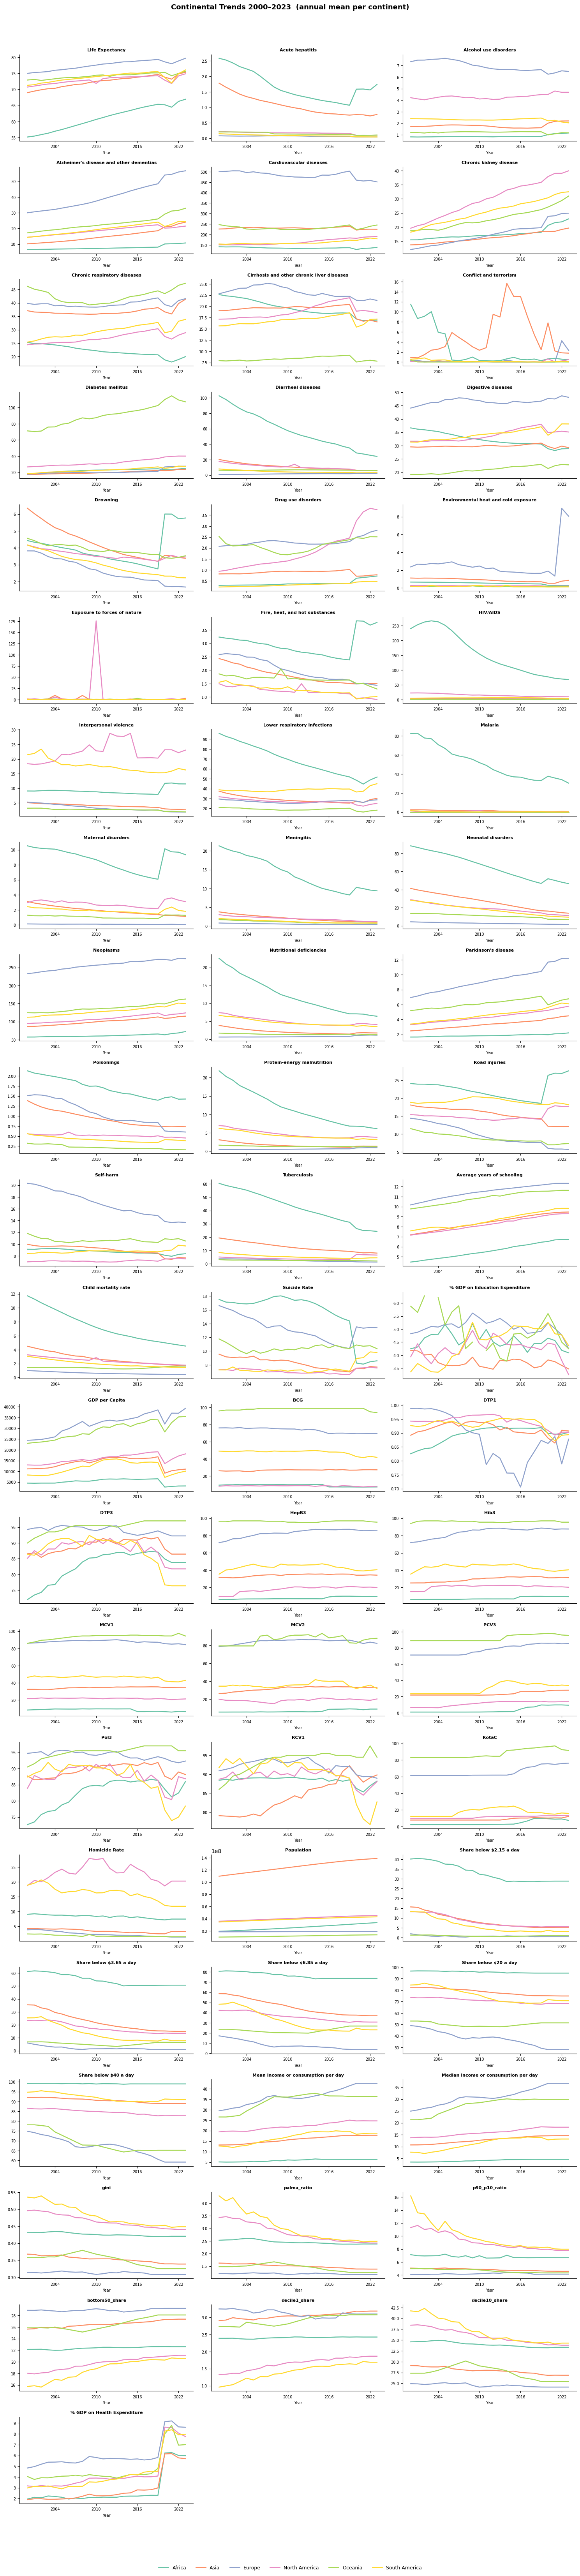

In [10]:
# ── 2b. Continental divergence — one line per continent ────────────────────────

def plot_continental_trends(df, cols, continent_col='Continent', ncols=3):
    """
    Line chart per continent for each feature, 2000–2023.
    Highlights which continents are catching up vs. diverging.
    """
    if continent_col not in df.columns:
        print(f'Column "{continent_col}" not found. Skipping continental trends.')
        return

    yearly_cont = df.groupby(['Year', continent_col])[cols].mean().reset_index()
    continents  = yearly_cont[continent_col].unique()

    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 3))
    axes = axes.flatten()

    for ax, col in zip(axes, cols):
        for cont in continents:
            subset = yearly_cont[yearly_cont[continent_col] == cont]
            ax.plot(subset['Year'], subset[col],
                    color=CONTINENT_COLORS.get(cont, '#888'),
                    linewidth=1.8, label=cont)

        ax.set_title(col, fontsize=8, fontweight='bold')
        ax.set_xlabel('Year', fontsize=7)
        ax.tick_params(labelsize=7)
        ax.spines[['top', 'right']].set_visible(False)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(5, integer=True))

    for ax in axes[len(cols):]:
        ax.set_visible(False)

    # Shared legend
    handles = [plt.Line2D([0], [0], color=CONTINENT_COLORS.get(c, '#888'),
                           linewidth=2, label=c) for c in continents]
    fig.legend(handles=handles, loc='lower center', ncol=len(handles),
               fontsize=9, bbox_to_anchor=(0.5, -0.02), frameon=False)

    plt.suptitle('Continental Trends 2000–2023  (annual mean per continent)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

plot_continental_trends(df, all_numeric)

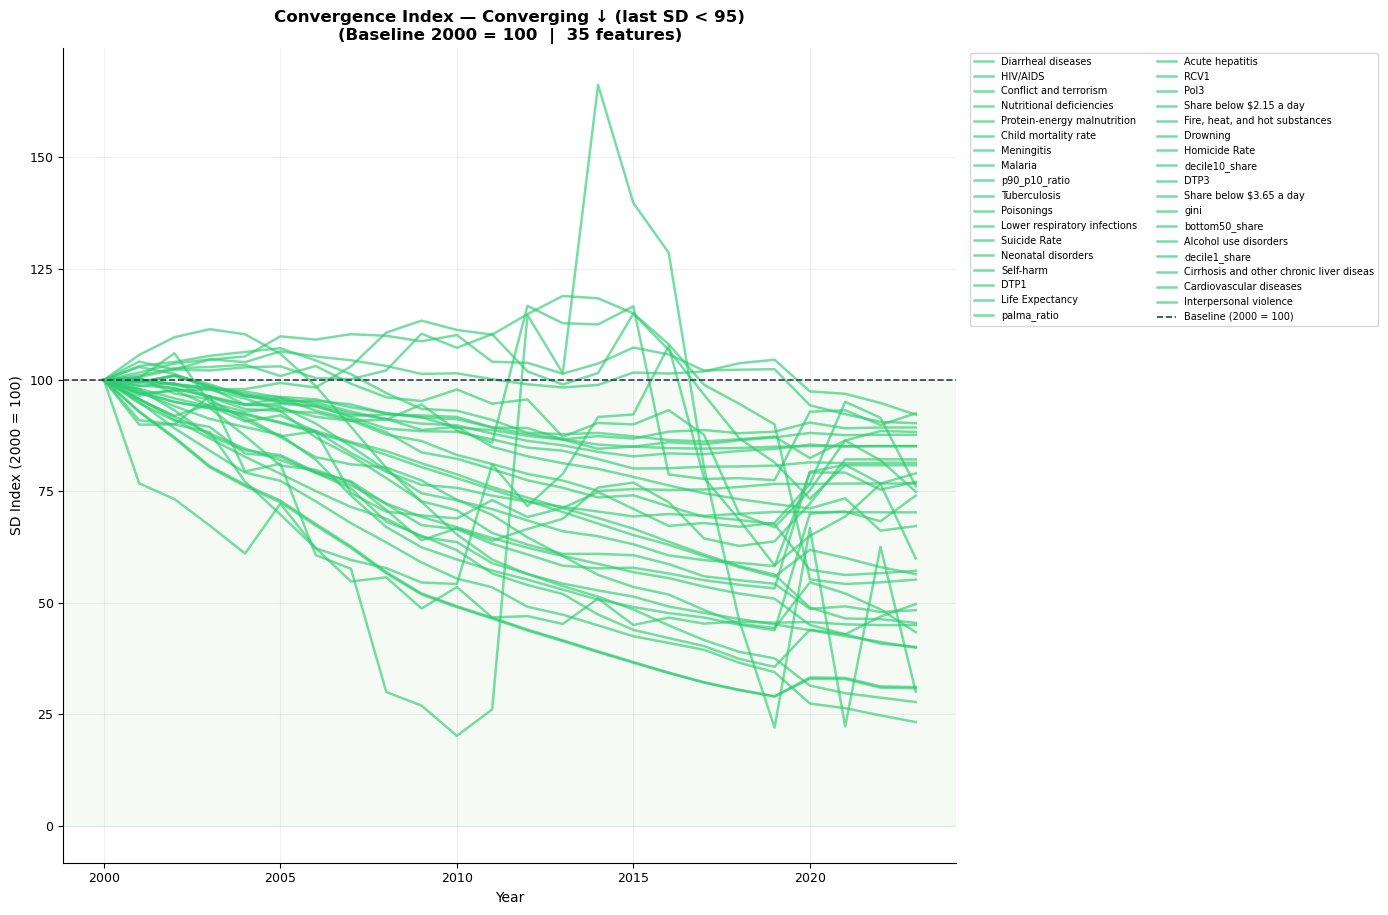


📊 Converging ↓ (last SD < 95):
  Diarrheal diseases                                 final index = 23.2
  HIV/AIDS                                           final index = 27.7
  Conflict and terrorism                             final index = 30.1
  Nutritional deficiencies                           final index = 30.8
  Protein-energy malnutrition                        final index = 31.1
  Child mortality rate                               final index = 39.9
  Meningitis                                         final index = 40.1
  Malaria                                            final index = 43.4
  p90_p10_ratio                                      final index = 45.0
  Tuberculosis                                       final index = 45.5
  Poisonings                                         final index = 48.4
  Lower respiratory infections                       final index = 49.7
  Suicide Rate                                       final index = 55.2
  Neonatal disorders            

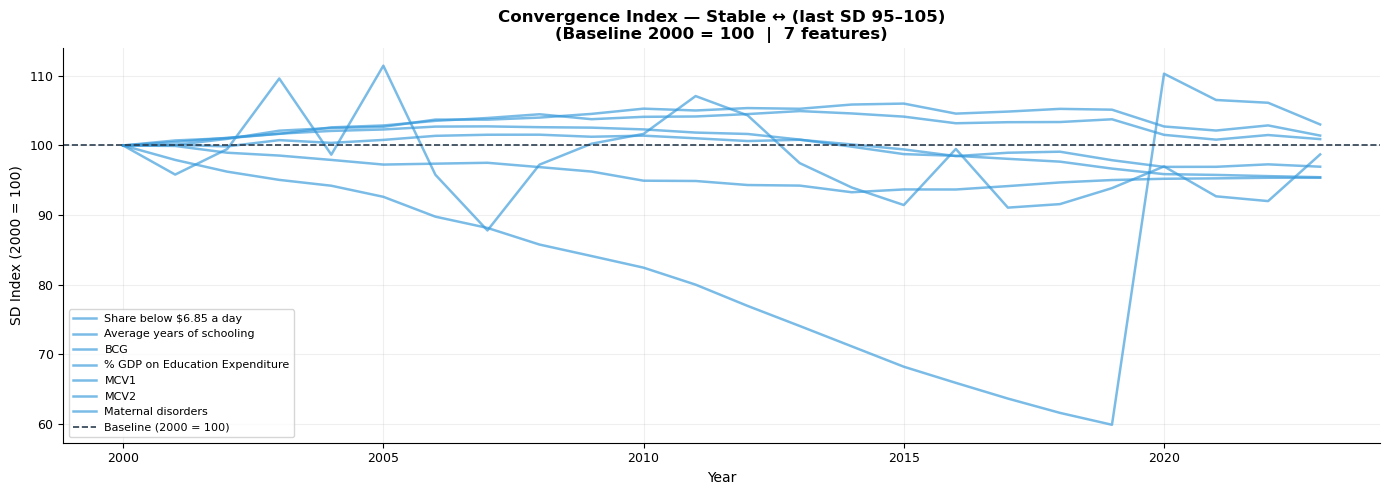


📊 Stable ↔ (last SD 95–105):
  Share below $6.85 a day                            final index = 95.4
  Average years of schooling                         final index = 95.4
  BCG                                                final index = 96.9
  % GDP on Education Expenditure                     final index = 98.7
  MCV1                                               final index = 100.9
  MCV2                                               final index = 101.4
  Maternal disorders                                 final index = 103.0


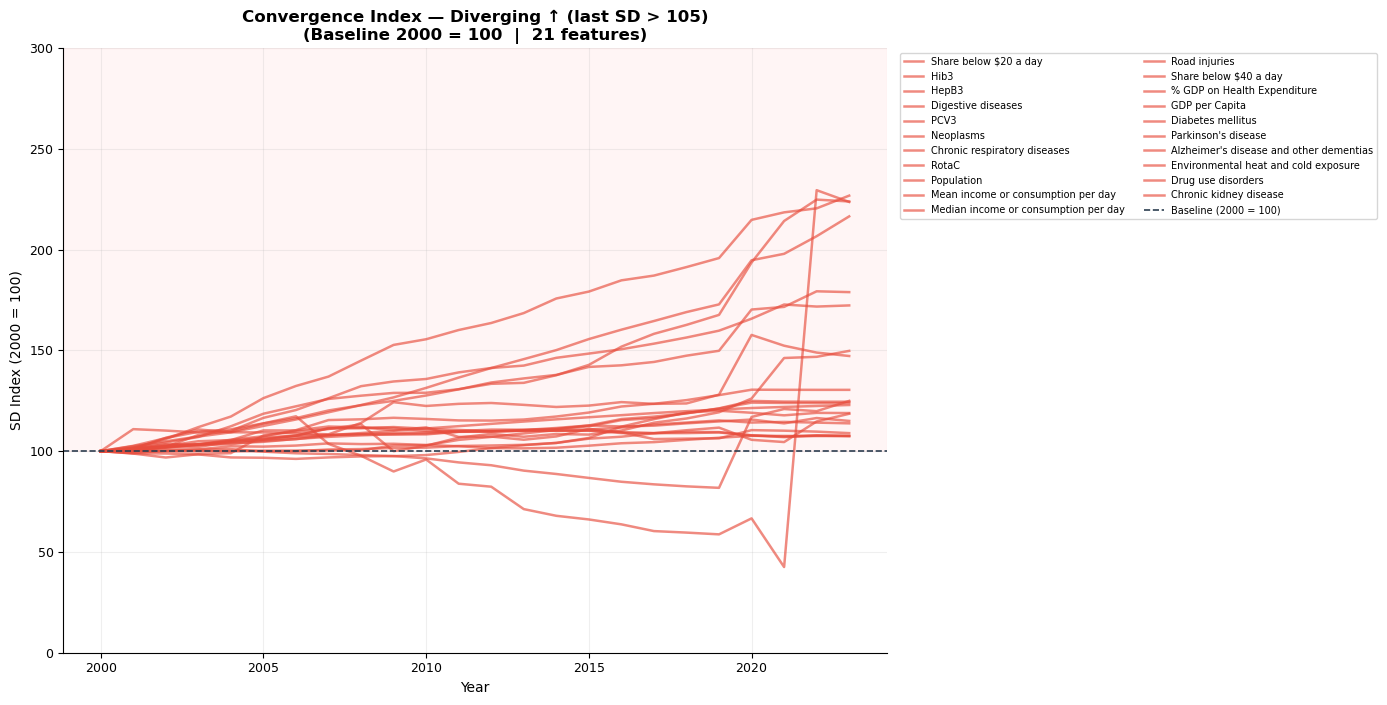


📊 Diverging ↑ (last SD > 105):
  Share below $20 a day                              final index = 107.5
  Hib3                                               final index = 107.5
  HepB3                                              final index = 107.6
  Digestive diseases                                 final index = 108.9
  PCV3                                               final index = 113.8
  Neoplasms                                          final index = 115.0
  Chronic respiratory diseases                       final index = 118.5
  RotaC                                              final index = 118.9
  Population                                         final index = 122.9
  Mean income or consumption per day                 final index = 123.9
  Median income or consumption per day               final index = 124.5
  Road injuries                                      final index = 124.9
  Share below $40 a day                              final index = 130.4
  % GDP on Health E

In [11]:
def plot_convergence_all_features(df, cols, baseline_year=2000, y_cap=300):
    """
    Plots three separate charts:
    - Chart 1: Converging features (last SD < 95)
    - Chart 2: Stable features (last SD 95-105)
    - Chart 3: Diverging features (last SD > 105, capped at y_cap)
    """
    sd_data = {}
    for col in cols:
        yearly_sd = df.groupby('Year')[col].std()
        base = yearly_sd.get(baseline_year, np.nan)
        if pd.notna(base) and base != 0:
            sd_data[col] = (yearly_sd / base * 100)

    if not sd_data:
        print('No valid features for convergence analysis.')
        return

    conv_df = pd.DataFrame(sd_data)

    # Group by last value
    last_vals  = conv_df.iloc[-1].sort_values()
    converging = last_vals[last_vals < 95].index.tolist()
    stable     = last_vals[(last_vals >= 95) & (last_vals <= 105)].index.tolist()
    diverging  = last_vals[last_vals > 105].index.tolist()

    # Separate extreme outliers from diverging
    extreme_features = [f for f in diverging if conv_df[f].max() > y_cap]
    diverging_clean  = [f for f in diverging if conv_df[f].max() <= y_cap]

    groups = [
        ('Converging ↓ (last SD < 95)',  converging,     '#2ecc71', None),
        ('Stable ↔ (last SD 95–105)',     stable,         '#3498db', None),
        ('Diverging ↑ (last SD > 105)',   diverging_clean,'#e74c3c', y_cap),
    ]

    for title, features, color, y_limit in groups:
        if not features:
            print(f'⚠️  No features in group: {title}')
            continue

        # Dynamic figure height based on number of features
        fig_height = max(5, min(10, 4 + len(features) * 0.15))
        fig, ax = plt.subplots(figsize=(14, fig_height))

        for feat in features:
            ax.plot(conv_df.index, conv_df[feat],
                    linewidth=1.8, color=color, alpha=0.65, label=feat[:40])

        ax.axhline(100, color='#2c3e50', linestyle='--',
                   linewidth=1.2, label='Baseline (2000 = 100)')

        # Shade convergence/divergence zones
        if 'Converging' in title:
            ax.axhspan(0,   100, color='green', alpha=0.04)
        elif 'Diverging' in title:
            ax.axhspan(100, y_cap if y_limit else 300,
                       color='red', alpha=0.04)
            if y_limit:
                ax.set_ylim(0, y_limit)

        ax.set_title(
            f'Convergence Index — {title}\n'
            f'(Baseline {baseline_year} = 100  |  '
            f'{len(features)} features)',
            fontsize=12, fontweight='bold'
        )
        ax.set_xlabel('Year', fontsize=10)
        ax.set_ylabel('SD Index (2000 = 100)', fontsize=10)
        ax.tick_params(labelsize=9)
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(True, alpha=0.2)

        # Legend — outside right if many features, inside if few
        if len(features) > 10:
            ax.legend(fontsize=7, ncol=2,
                      bbox_to_anchor=(1.01, 1), loc='upper left',
                      frameon=True, framealpha=0.8)
        else:
            ax.legend(fontsize=8, ncol=1,
                      loc='best', frameon=True, framealpha=0.8)

        plt.tight_layout()
        plt.show()

        # Per-group summary
        print(f'\n📊 {title}:')
        for f in sorted(features, key=lambda x: last_vals[x]):
            print(f'  {f:<50s} final index = {last_vals[f]:.1f}')

    # Extreme outliers report
    if extreme_features:
        print(f'\n⚠️  Extreme divergers (max SD > {y_cap}x baseline) — not plotted:')
        for f in extreme_features:
            print(f'  {f:<50s} max index = {conv_df[f].max():.1f}')


plot_convergence_all_features(df, all_numeric, y_cap=300)

---
# **3. Outlier Detection & Documentation**

Two complementary methods:
- **IQR method** — flags observations where value < Q1 − 1.5·IQR or > Q3 + 1.5·IQR
- **Z-score method** — flags |z| > 3 (>3 standard deviations from the mean)

We apply these at the **country-profile level** (latest-year snapshot) to identify structurally anomalous countries, and separately at the **panel level** to find data entry errors or extreme single-year spikes.

In [12]:
# ── 3a. Country-profile outlier detection (latest year per country) ────────────

df_latest = df.sort_values('Year').groupby('Country').last().reset_index()

def detect_outliers_iqr(df, cols):
    """Flag IQR outliers. Returns a boolean DataFrame (True = outlier)."""
    flags = pd.DataFrame(False, index=df.index, columns=cols)
    for col in cols:
        s = df[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        flags[col] = (df[col] < lower) | (df[col] > upper)
    return flags

def detect_outliers_zscore(df, cols, threshold=3.0):
    """Flag z-score outliers. Returns a boolean DataFrame."""
    flags = pd.DataFrame(False, index=df.index, columns=cols)
    for col in cols:
        z = np.abs(stats.zscore(df[col].fillna(df[col].median())))
        flags[col] = z > threshold
    return flags


flags_iqr   = detect_outliers_iqr(df_latest, feature_cols)
flags_z     = detect_outliers_zscore(df_latest, feature_cols)
flags_both  = flags_iqr & flags_z  # conservative: flagged by BOTH methods

df_latest['n_outlier_flags_iqr']  = flags_iqr.sum(axis=1)
df_latest['n_outlier_flags_z']    = flags_z.sum(axis=1)
df_latest['n_outlier_flags_both'] = flags_both.sum(axis=1)

print('Countries with the most outlier flags (flagged by BOTH IQR + z-score):')
top_outliers = (df_latest[['Country', 'Continent', 'Life Expectancy',
                             'n_outlier_flags_iqr', 'n_outlier_flags_z', 'n_outlier_flags_both']]
                .sort_values('n_outlier_flags_both', ascending=False)
                .head(20))
display(top_outliers)

Countries with the most outlier flags (flagged by BOTH IQR + z-score):


,Country,Continent,Life Expectancy,n_outlier_flags_iqr,n_outlier_flags_z,n_outlier_flags_both
84,Niger,Africa,61.183,15,11,11
17,Burundi,Africa,63.651,16,6,6
104,South Africa,Africa,66.139,11,6,6
45,Haiti,North America,64.936,15,5,5
101,Sierra Leone,Africa,61.786,10,5,5
80,Namibia,Africa,67.385,12,4,4
63,Lesotho,Africa,57.375,10,3,3
19,Cameroon,Africa,63.700,11,3,3
66,Luxembourg,Europe,82.229,4,3,3
74,Moldova,Europe,71.198,5,3,3


Outlier count per feature:


,IQR Outlier Countries,Z-score Outlier Countries,Both Methods
Malaria,28,6,6
Maternal disorders,19,5,5
Homicide Rate,14,5,5
HIV/AIDS,21,4,4
Share below $2.15 a day,24,4,4
...,...,...,...
HepB3,0,0,0
RotaC,0,0,0
Hib3,0,0,0
MCV1,0,0,0


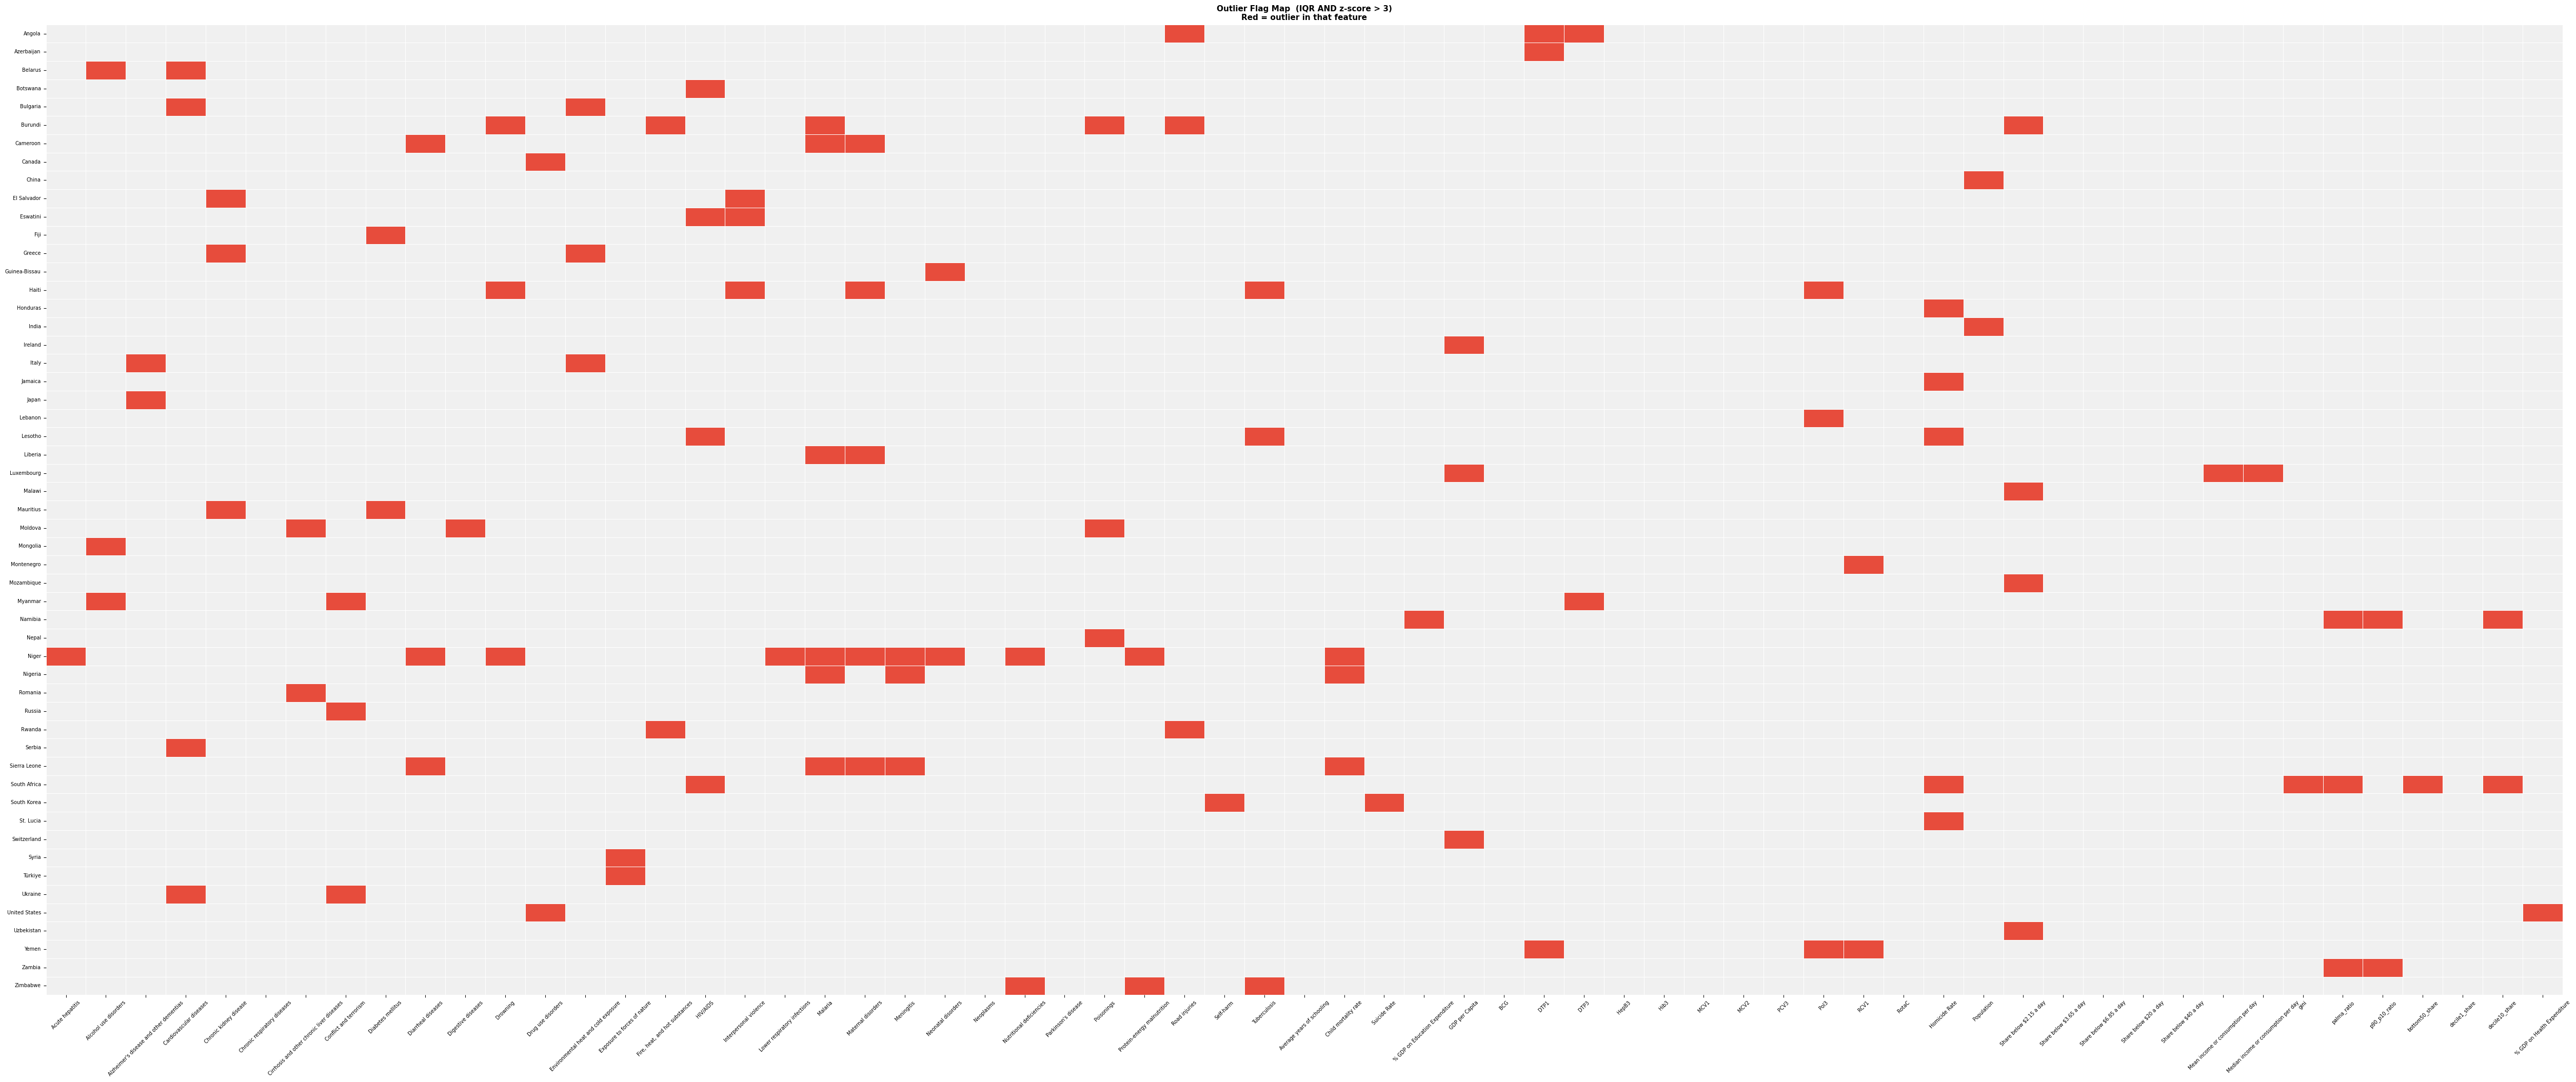

In [13]:
# ── 3b. Per-feature outlier map ────────────────────────────────────────────────

# Which features have the most outlier countries?
outlier_feature_summary = pd.DataFrame({
    'IQR Outlier Countries':  flags_iqr.sum(),
    'Z-score Outlier Countries': flags_z.sum(),
    'Both Methods':           flags_both.sum(),
}).sort_values('Both Methods', ascending=False)

print('Outlier count per feature:')
display(outlier_feature_summary)

# Visual: heatmap of outlier flags (countries × features)
flag_heat = flags_both.copy()
flag_heat.index = df_latest['Country'].values
flag_heat = flag_heat.loc[flag_heat.any(axis=1)]  # keep only countries with at least one flag

if not flag_heat.empty:
    fig, ax = plt.subplots(figsize=(max(14, len(flag_heat.columns) * 0.8),
                                     max(6,  len(flag_heat)         * 0.4)))
    sns.heatmap(flag_heat.astype(int), ax=ax, cmap=['#f0f0f0', '#e74c3c'],
                linewidths=0.5, linecolor='white', cbar=False,
                xticklabels=True, yticklabels=True)
    ax.set_title('Outlier Flag Map  (IQR AND z-score > 3)\nRed = outlier in that feature',
                 fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', labelsize=7, rotation=45)
    ax.tick_params(axis='y', labelsize=7)
    plt.tight_layout()
    plt.show()
else:
    print('No countries flagged by both methods simultaneously.')

In [14]:
# ── 3c. Panel-level spike detection (year-over-year jumps) ─────────────────────
# Catches data entry errors: a single year where a value jumps abnormally.

def detect_panel_spikes(df, cols, z_threshold=4.0):
    """
    Within each country, compute year-over-year change for each feature.
    Flag country-year pairs where the YoY change is beyond z_threshold SDs
    of that country's own historical change distribution.
    """
    spike_records = []
    for country, grp in df.groupby('Country'):
        grp = grp.sort_values('Year')
        for col in cols:
            diff = grp[col].diff()
            mean_d, std_d = diff.mean(), diff.std()
            if std_d == 0 or pd.isna(std_d):
                continue
            z = (diff - mean_d) / std_d
            spikes = grp[z.abs() > z_threshold]
            for _, row in spikes.iterrows():
                spike_records.append({
                    'Country': country,
                    'Year':    row['Year'],
                    'Feature': col,
                    'Value':   row[col],
                    'YoY Change': diff[row.name],
                    'Z-score': z[row.name],
                })

    return pd.DataFrame(spike_records).sort_values('Z-score', key=abs, ascending=False)


df_spikes = detect_panel_spikes(df, feature_cols)

print(f'Panel spike events detected: {len(df_spikes)}')
print('Top 30 most extreme single-year jumps:')
display(df_spikes.head(50))

Panel spike events detected: 1635
Top 30 most extreme single-year jumps:


,Country,Year,Feature,Value,YoY Change,Z-score
813,Luxembourg,2001,Exposure to forces of nature,0.000,-0.459,-4.587
788,Lesotho,2008,Homicide Rate,37.694,-7.429,-4.587
559,Guinea-Bissau,2017,Homicide Rate,1.117,-2.371,-4.587
1076,Niger,2012,Homicide Rate,4.389,-0.419,-4.587
887,Mauritania,2023,MCV2,0.265,0.265,4.587
694,Jamaica,2023,Conflict and terrorism,0.000,0.000,4.587
321,Croatia,2022,PCV3,90.000,15.000,4.587
1211,Russia,2023,Hib3,95.000,7.000,4.587
1142,Pakistan,2023,RCV1,84.000,2.000,4.587
1477,Uganda,2021,RCV1,90.000,1.000,4.587


In [15]:
df_spikes.to_csv('Phase_A_docs/panel_spike_log.csv', index=False)
#print('\n✅ Saved: panel_spike_log.csv')

In [16]:
# ── 3d. Formal Outlier Decision Log ───────────────────────────────────────────
# Document every exclusion or treatment decision for reproducibility.
# Update this cell after reviewing results above.

outlier_decisions = [
    #{
    #    'Country':    'Nigeria',
    #    'Feature':    'Multiple (health expenditure, vaccination)',
    #    'Detection':  'Manual review during clustering (framework_b_clustering.ipynb)',
    #    'Decision':   'EXCLUDE from clustering — data-integrity concern, not outcome-based exclusion',
    #    'Rationale':  'Reported health expenditure and vaccination figures inconsistent across sources and years. '
    #                  'Nigeria remains in the main imputed dataset for correlation/ML modeling.'
    #},
    # ── Add rows here as you review the spike log and outlier heatmap above ──
    # Example template:
    # {
    #     'Country':   'XXX',
    #     'Feature':   'GDP per Capita',
    #     'Detection': 'IQR + Z-score (both methods, profile level)',
    #     'Decision':  'KEEP — structural outlier (oil economy), not a data error',
    #     'Rationale': 'Country is genuinely extreme; cap winsorize at 99th percentile in Phase C if needed.'
    # },
]

df_outlier_log = pd.DataFrame(outlier_decisions)

print('Formal Outlier Decision Log')
display(df_outlier_log)

Formal Outlier Decision Log


""


In [17]:
df_outlier_log.to_csv('Phase_A_docs/outlier_decision_log.csv', index=False)

print('\n⚠️  ACTION REQUIRED: Review panel_spike_log.csv and outlier_flag_map.png,')
print('   then add decisions to the outlier_decisions list above and re-run.')


⚠️  ACTION REQUIRED: Review panel_spike_log.csv and outlier_flag_map.png,
   then add decisions to the outlier_decisions list above and re-run.


---
# **4. Feature Engineering Log**

A formal audit trail documenting:
1. Every raw source file and the columns extracted from it
2. Transformation decisions (rename, melt, aggregate, impute)
3. Columns dropped and why
4. Final column inventory in `df_merged_all_imputed.csv`
5. Recommendations for Phase C (log-transforms, interaction terms, lags)

In [18]:
# ── 4a. Raw Source → Final Column Mapping ────────────────────────────────────

# This documents the pipeline from raw CSVs to df_merged_all_imputed.csv.
# Update 'raw_column' and 'drop_reason' entries as needed.

feature_engineering_log = [
    # ── Life Expectancy (Target) ──────────────────────────────────────────────
    {'source_file': 'life_expectancy',
     'raw_column':  'Period life expectancy at birth',
     'final_column': 'Life Expectancy',
     'transformation': 'Rename',
     'kept': True,
     'role': 'TARGET',
     'drop_reason': ''},

    # ── Demographics ──────────────────────────────────────────────────────────
    {'source_file': 'population',
     'raw_column':  'Population - Sex: all - Age: all - Variant: estimates',
     'final_column': 'Population',
     'transformation': 'Rename',
     'kept': True,
     'role': 'CONTROL',
     'drop_reason': ''},

    {'source_file': 'child-mortality',
     'raw_column':  'Child mortality rate',
     'final_column': 'Child Mortality Rate',
     'transformation': 'Rename',
     'kept': True,
     'role': 'FEATURE',
     'drop_reason': ''},

    # ── Economic ──────────────────────────────────────────────────────────────
    {'source_file': 'gdp_per_capita_penn_world_table',
     'raw_column':  'GDP per Capita',
     'final_column': 'GDP per Capita',
     'transformation': 'Aggregated from Penn World Table + World Bank gap-fill (2020, 2023)',
     'kept': True,
     'role': 'FEATURE',
     'drop_reason': ''},

    {'source_file': 'gdp_health_expenditure',
     'raw_column':  'Health Expenditure (% GDP)',
     'final_column': 'Health Expenditure (% GDP)',
     'transformation': 'Aggregated from IHME; gap-filled 2020/2023',
     'kept': True,
     'role': 'FEATURE',
     'drop_reason': ''},

    # ── Education ─────────────────────────────────────────────────────────────
    {'source_file': 'average-years-of-schooling-among-adults',
     'raw_column':  'Average years of schooling',
     'final_column': 'Education (years)',
     'transformation': 'Rename',
     'kept': True,
     'role': 'FEATURE',
     'drop_reason': ''},

    {'source_file': 'education_spending_share_gdp',
     'raw_column':  'Education spending (% GDP)',
     'final_column': 'Education Spending (% GDP)',
     'transformation': 'Melted from wide format',
     'kept': True,
     'role': 'FEATURE',
     'drop_reason': ''},

    # ── Poverty & Inequality ──────────────────────────────────────────────────
    {'source_file': 'poverty_explorer',
     'raw_column':  'Share below $6.85 a day',
     'final_column': 'Poverty ($6.85/day)',
     'transformation': 'Selected from multiple poverty thresholds; $6.85 chosen as WHO lower-middle benchmark',
     'kept': True,
     'role': 'FEATURE',
     'drop_reason': ''},

    {'source_file': 'poverty_explorer',
     'raw_column':  'Share below $2.15 a day',
     'final_column': 'Poverty ($2.15/day)',
     'transformation': 'Selected from poverty_explorer',
     'kept': False,
     'role': 'DROPPED',
     'drop_reason': 'High collinearity with $6.85 threshold (r > 0.95). $6.85 retained as broader coverage measure.'},

    {'source_file': 'poverty_explorer',
     'raw_column':  'Share below $3.65 a day',
     'final_column': 'Poverty ($3.65/day)',
     'transformation': 'Selected from poverty_explorer',
     'kept': False,
     'role': 'DROPPED',
     'drop_reason': 'High collinearity with $6.85 threshold. Redundant.'},

    # ── Vaccination ───────────────────────────────────────────────────────────
    {'source_file': 'global_vaccination_coverage',
     'raw_column':  'DTP3',
     'final_column': 'DTP3',
     'transformation': 'Merged local WHO Excel files + OWID gap-fill (2020, 2023)',
     'kept': True,
     'role': 'FEATURE',
     'drop_reason': ''},

    {'source_file': 'global_vaccination_coverage',
     'raw_column':  'MCV1, HepB3, Hib3, Pol3, PCV3',
     'final_column': 'MCV1, HepB3, Hib3, Pol3, PCV3',
     'transformation': 'Merged and normalized antigen names',
     'kept': True,
     'role': 'FEATURE',
     'drop_reason': ''},

    # ── Mortality Causes ──────────────────────────────────────────────────────
    {'source_file': 'annual_number_of_deaths_by_cause',
     'raw_column':  'Deaths - [cause] - Sex: Both - Age: All Ages (Number)',
     'final_column': 'Deaths - Causes',
     'transformation': 'Renamed (stripped prefix/suffix). Wide format retained.',
     'kept': True,
     'role': 'FEATURE',
     'drop_reason': ''},

    # ── Social ────────────────────────────────────────────────────────────────
    {'source_file': 'death_rate_from_suicides_gho',
     'raw_column':  'Age-standardized suicide rate - Sex: both sexes',
     'final_column': 'Suicide Rate',
     'transformation': 'Rename + gap-fill 2020/2023 from World Population Review',
     'kept': True,
     'role': 'FEATURE',
     'drop_reason': ''},

    {'source_file': 'homicide_rate_unodc',
     'raw_column':  'Homicide rate per 100,000 population - Both sexes - All ages',
     'final_column': 'Homicide Rate',
     'transformation': 'Rename',
     'kept': True,
     'role': 'FEATURE',
     'drop_reason': ''},
]

df_fe_log = pd.DataFrame(feature_engineering_log)
df_fe_log.to_csv('Phase_A_docs/feature_engineering_log.csv', index=False)

print('Feature Engineering Log')
print(f'  Total entries: {len(df_fe_log)}')
print(f'  Kept:    {df_fe_log["kept"].sum()}')
print(f'  Dropped: {(~df_fe_log["kept"]).sum()}')
print()
display(df_fe_log)

Feature Engineering Log
  Total entries: 15
  Kept:    13
  Dropped: 2



,source_file,raw_column,final_column,transformation,kept,role,drop_reason
0,life_expectancy,Period life expectancy at birth,Life Expectancy,Rename,True,TARGET,
1,population,Population - Sex: all - Age: all - Variant: es...,Population,Rename,True,CONTROL,
2,child-mortality,Child mortality rate,Child Mortality Rate,Rename,True,FEATURE,
3,gdp_per_capita_penn_world_table,GDP per Capita,GDP per Capita,Aggregated from Penn World Table + World Bank ...,True,FEATURE,
4,gdp_health_expenditure,Health Expenditure (% GDP),Health Expenditure (% GDP),Aggregated from IHME; gap-filled 2020/2023,True,FEATURE,
5,average-years-of-schooling-among-adults,Average years of schooling,Education (years),Rename,True,FEATURE,
6,education_spending_share_gdp,Education spending (% GDP),Education Spending (% GDP),Melted from wide format,True,FEATURE,
7,poverty_explorer,Share below $6.85 a day,Poverty ($6.85/day),Selected from multiple poverty thresholds; $6....,True,FEATURE,
8,poverty_explorer,Share below $2.15 a day,Poverty ($2.15/day),Selected from poverty_explorer,False,DROPPED,High collinearity with $6.85 threshold (r > 0....
9,poverty_explorer,Share below $3.65 a day,Poverty ($3.65/day),Selected from poverty_explorer,False,DROPPED,High collinearity with $6.85 threshold. Redund...


In [19]:
# ── 4b. Final Column Inventory — auto-generated from df_merged_all_imputed.csv ─

inventory_rows = []
for col in df.columns:
    s = df[col]
    dtype = str(s.dtype)
    missing = s.isna().mean() * 100
    is_numeric = pd.api.types.is_numeric_dtype(s)
    role = ('ID' if col in ['Country', 'Continent', 'Year']
            else 'TARGET' if col == TARGET
            else 'FEATURE' if is_numeric
            else 'CATEGORICAL')

    row = {
        'Column':     col,
        'Dtype':      dtype,
        'Role':       role,
        'Missing %':  round(missing, 1),
    }
    if is_numeric:
        row['Mean']  = round(s.mean(), 3)
        row['Std']   = round(s.std(), 3)
        row['Min']   = round(s.min(), 3)
        row['Max']   = round(s.max(), 3)
    inventory_rows.append(row)

df_inventory = pd.DataFrame(inventory_rows)
df_inventory.to_csv('Phase_A_docs/final_column_inventory.csv', index=False)

print(f'Final column inventory: {len(df_inventory)} columns')
display(df_inventory)

Final column inventory: 67 columns


,Column,Dtype,Role,Missing %,Mean,Std,Min,Max
0,Country,object,ID,0.000,NaN,NaN,NaN,NaN
1,Year,int64,ID,0.000,2011.500,6.923,2000.000,2023.000
2,Acute hepatitis,float64,FEATURE,0.000,0.731,1.150,0.000,8.136
3,Alcohol use disorders,float64,FEATURE,0.000,3.411,5.219,0.010,37.862
4,Alzheimer's disease and other dementias,float64,FEATURE,0.000,21.961,18.790,0.805,167.716
...,...,...,...,...,...,...,...,...
62,bottom50_share,float64,FEATURE,0.000,24.931,4.997,10.248,33.983
63,decile1_share,float64,FEATURE,0.000,2.639,0.896,0.133,4.847
64,decile10_share,float64,FEATURE,0.000,29.903,6.538,18.450,54.788
65,% GDP on Health Expenditure,float64,FEATURE,0.000,4.134,2.642,0.121,18.516


In [20]:
# ── 4c. Phase C Recommendations — log-transforms, interactions, lags ──────────

print('=' * 70)
print('PHASE C FEATURE ENGINEERING RECOMMENDATIONS')
print('=' * 70)

print('\n📌 1. Log-transform these highly skewed features before modeling:')
print('   (Skewness > 1 detected in Section 1 above)')
for feat in high_skew:
    skew_val = df_summary.loc[feat, 'Skewness'] if feat in df_summary.index else 'N/A'
    print(f'   → log1p({feat})   [skew = {skew_val}]')

print('\n📌 2. Suggested interaction terms (theory-grounded):')
interactions = [
    ('GDP per Capita', 'Health Expenditure (% GDP)',
     'Absolute health spending per capita — more actionable than % alone'),
    ('GDP per Capita', 'Education (years)',
     'Human capital weighted by economic context (Preston curve extension)'),
    ('DTP3', 'Child Mortality Rate',
     'Vaccination coverage × child mortality — pathway analysis'),
    ('Education (years)', 'Health Expenditure (% GDP)',
     'Education × health investment — compound human development'),
]
for f1, f2, rationale in interactions:
    print(f'   → {f1} × {f2}')
    print(f'      Rationale: {rationale}')

print('\n📌 3. Lagged features to consider (1-year and 3-year lags):')
lag_candidates = [
    ('DTP3',                     'Vaccination effects on mortality take 1–3 years to manifest'),
    ('Health Expenditure (% GDP)', 'Capital investments in health infrastructure have delayed returns'),
    ('Education (years)',         'Education effects on health behaviour accumulate over time'),
    ('GDP per Capita',           'Economic growth → health improvements with delay'),
]
for feat, rationale in lag_candidates:
    print(f'   → {feat} (lag 1yr, lag 3yr)')
    print(f'      Rationale: {rationale}')

print('\n📌 4. Country fixed effects / group encodings:')
print('   → Include continent dummies or country-level random effects')
print('   → Consider income-group encoding (WB classification: LIC/LMIC/UMIC/HIC)')
print('   → Consider SDI quintile encoding from GBD data')

print('\n📌 5. Train/test split strategy for panel data:')
print('   → DO NOT use random split — this leaks future observations into training.')
print('   → Option A (recommended): Temporal split — train on 2000–2017, test on 2018–2023')
print('   → Option B: Country holdout — hold out 20% of countries for testing')
print('   → Option C: Combination — temporal split within country groups')

PHASE C FEATURE ENGINEERING RECOMMENDATIONS

📌 1. Log-transform these highly skewed features before modeling:
   (Skewness > 1 detected in Section 1 above)
   → log1p(Acute hepatitis)   [skew = 2.406]
   → log1p(Alcohol use disorders)   [skew = 2.959]
   → log1p(Alzheimer's disease and other dementias)   [skew = 1.635]
   → log1p(Cardiovascular diseases)   [skew = 1.704]
   → log1p(Chronic kidney disease)   [skew = 2.238]
   → log1p(Chronic respiratory diseases)   [skew = 1.516]
   → log1p(Cirrhosis and other chronic liver diseases)   [skew = 2.237]
   → log1p(Conflict and terrorism)   [skew = 13.365]
   → log1p(Diabetes mellitus)   [skew = 4.104]
   → log1p(Diarrheal diseases)   [skew = 3.228]
   → log1p(Digestive diseases)   [skew = 1.18]
   → log1p(Drowning)   [skew = 1.994]
   → log1p(Drug use disorders)   [skew = 5.012]
   → log1p(Environmental heat and cold exposure)   [skew = 4.912]
   → log1p(Exposure to forces of nature)   [skew = 53.636]
   → log1p(Fire, heat, and hot substan

---
## **~Summary: Phase A Supplement Outputs~**

| File | Description |
|------|-------------|
| `univariate_summary.csv` | Descriptive stats + skew/kurtosis flags for all features |
| `univariate_distributions.png` | Histogram + continent KDE per feature |
| `log_transform_candidates.png` | Raw vs log1p comparison for high-skew features |
| `global_trends.png` | Global mean ± SD trend 2000–2023 for all features |
| `continental_trends.png` | Annual mean per continent for all features |
| `convergence_index_all.png` | SD convergence index (2000 = 100) for all features |
| `outlier_flag_map.png` | Heatmap of countries × features flagged by IQR + z-score |
| `panel_spike_log.csv` | Year-over-year spike events (potential data errors) |
| `outlier_decision_log.csv` | Formal exclusion/treatment decisions per country |
| `feature_engineering_log.csv` | Raw source → final column mapping with drop rationale |
| `final_column_inventory.csv` | Auto-generated inventory of all columns in imputed dataset |

### Next Steps
1. Review `panel_spike_log.csv` and add decisions to `outlier_decision_log` (cell 3d)
2. Update `feature_engineering_log` (cell 4a) with any additional columns from your actual dataset
3. Proceed to **Phase B** `correlations.ipynb` — the VIF analysis and lag correlations there are the remaining gaps before Phase C modeling